# L63 Forecasting with `predict_times`-Only Simulator Rollouts

This notebook mirrors the L63 forecast workflow but verifies the new simulator behavior where the **final** posterior-predictive rollout is called with only `predict_times` (no `obs_times`).

We cover simulator-based forecasting with full-state observations:

1. `ODESimulator`
2. `SDESimulator`
3. `Discretizer` + `DiscreteTimeSimulator` (linear-Gaussian observation)
4. `Discretizer` + `DiscreteTimeSimulator` + `DiracIdentityObservation`

For each simulator case:

- SVI is conditioned on `(obs_times, obs_values)`
- final `Predictive(...)` call uses only `predict_times`
- forecasts are plotted with uncertainty bands from posterior predictive draws.

In [1]:
from functools import partial

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist
import optax
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDiagonalNormal

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DiracIdentityObservation,
    DiscreteTimeSimulator,
    Discretizer,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    ODESimulator,
    SDESimulator,
)
from dynestyx.inference.filter_configs import ContinuousTimeEnKFConfig

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [ ]:
RHO_TRUE = 28.0
SIGMA = 10.0
BETA = 8.0 / 3.0
OBS_NOISE = 0.05


def model_l63(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    *,
    use_ode: bool = False,
    use_dirac_observation: bool = False,
):
    state_dim = 3

    def drift(x, u, t):
        del u, t
        return jnp.array(
            [
                SIGMA * (x[1] - x[0]),
                x[0] * (RHO_TRUE - x[2]) - x[1],
                x[0] * x[1] - BETA * x[2],
            ]
        )

    if use_ode:
        state_evolution = ContinuousTimeStateEvolution(
            drift=drift,
            diffusion_coefficient=None,
        )
    else:
        state_evolution = ContinuousTimeStateEvolution(
            drift=drift,
            diffusion_coefficient=lambda x, u, t: jnp.eye(
                                                          ),





        )

    if use_dirac_observation:
        observation_model = DiracIdentityObservation()
    else:
        observation_model = LinearGaussianObservation(
            H=jnp.eye(state_dim),
            R=(OBS_NOISE**2) * jnp.eye(state_dim),
        )

    dynamics = DynamicalModel(
        control_dim=0,
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim),
            covariance_matrix=0.01**2 * jnp.eye(state_dim),
        ),
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


model_sde = partial(model_l63, use_ode=False, use_dirac_observation=False)
model_ode = partial(model_l63, use_ode=True, use_dirac_observation=False)
model_dirac = partial(model_l63, use_ode=False, use_dirac_observation=True)

In [3]:
obs_times = jnp.arange(0.0, 3.0, 0.02)
predict_times = jnp.arange(float(obs_times[-1]) + 0.02, 4.0, 0.02)

with SDESimulator():
    synthetic = Predictive(
        model_sde,
        num_samples=1,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(0),
        obs_times=obs_times,
    )

obs_values = synthetic["observations"][0]

print("obs_times:", obs_times.shape)
print("predict_times:", predict_times.shape)
print("obs_values:", obs_values.shape)

obs_times: (150,)
predict_times: (50,)
obs_values: (150, 3)


In [4]:
def _plot_pred_only_from_draws(title, obs_times, obs_values, pred_times, pred_draws, dim=0):
    t_obs = jnp.asarray(obs_times)
    y_obs = jnp.asarray(obs_values)[:, dim]
    t_pred_arr = jnp.asarray(pred_times)
    t_pred = t_pred_arr[0] if t_pred_arr.ndim > 1 else t_pred_arr

    pred = jnp.asarray(pred_draws)[:, :, dim]
    pred_mean = pred.mean(axis=0)
    pred_std = pred.std(axis=0)

    plt.figure()
    plt.plot(t_obs, y_obs, "o", ms=2, alpha=0.7, label="observations")
    plt.plot(t_pred, pred_mean, "--", label="forecast mean")
    plt.fill_between(
        t_pred,
        pred_mean - 1.96 * pred_std,
        pred_mean + 1.96 * pred_std,
        alpha=0.25,
        label="95% band",
    )
    plt.axvline(float(t_obs[-1]), color="gray", linestyle=":")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(f"state dim {dim}")
    plt.legend(loc="best")
    plt.tight_layout()

100%|██████████| 100/100 [00:04<00:00, 21.77it/s, init loss: 82574.8672, avg. loss [96-100]: 31131.6836]


ODE SVI final ELBO: 22262.54296875


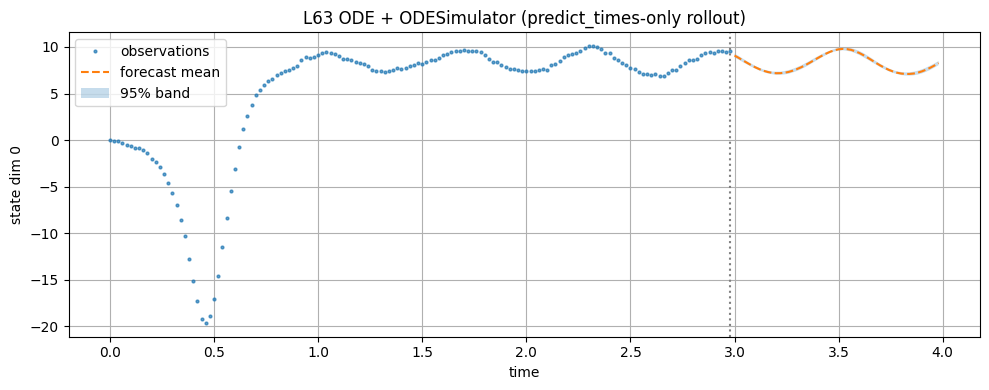

In [5]:
ode_steps = 100
ode_num_posterior_samples = 300

ode_guide = AutoDiagonalNormal(model_ode)
ode_svi = SVI(model_ode, ode_guide, optax.adam(1e-1), loss=Trace_ELBO())

with ODESimulator():
    ode_result = ode_svi.run(
        jr.PRNGKey(10),
        ode_steps,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    ode_posterior = ode_guide.sample_posterior(
        jr.PRNGKey(11),
        ode_result.params,
        sample_shape=(ode_num_posterior_samples,),
    )
    # Final rollout intentionally uses predict_times only (no obs_times).
    ode_out = Predictive(
        model_ode,
        posterior_samples=ode_posterior,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(12),
        predict_times=predict_times,
    )

print("ODE SVI final ELBO:", float(ode_result.losses[-1]))
_plot_pred_only_from_draws(
    "L63 ODE + ODESimulator (predict_times-only rollout)",
    obs_times,
    obs_values,
    ode_out["prediction_times"],
    ode_out["predicted_observations"],
    dim=0,
)

100%|██████████| 100/100 [03:16<00:00,  1.97s/it, init loss: 20153654.0000, avg. loss [96-100]: 4576904.0000]


SDE SVI final ELBO: 295374.1875


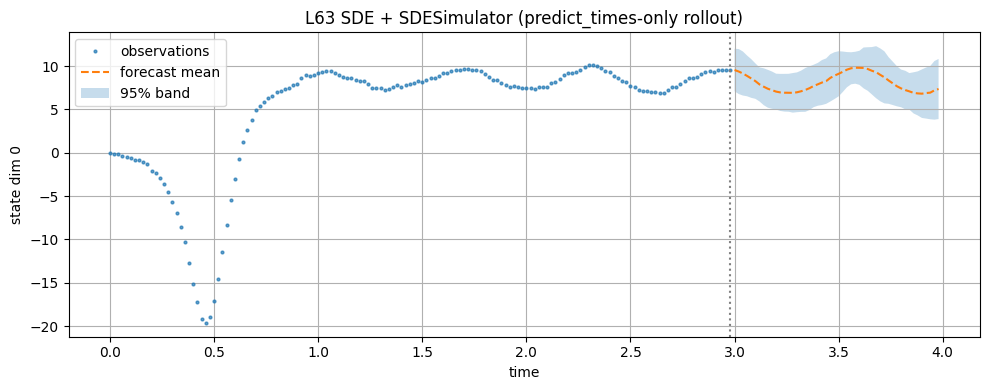

In [6]:
sde_steps = 100
sde_num_posterior_samples = 10

sde_guide = AutoDiagonalNormal(model_sde)
sde_svi = SVI(model_sde, sde_guide, optax.adam(2.5e-2), loss=Trace_ELBO())

with SDESimulator():
    sde_result = sde_svi.run(
        jr.PRNGKey(20),
        sde_steps,
        obs_times=obs_times,
        obs_values=obs_values,
    )
    sde_posterior = sde_guide.sample_posterior(
        jr.PRNGKey(21),
        sde_result.params,
        sample_shape=(sde_num_posterior_samples,),
    )
    sde_out = Predictive(
        model_sde,
        posterior_samples=sde_posterior,
        exclude_deterministic=False,
    )(
        jr.PRNGKey(22),
        predict_times=predict_times,
    )

print("SDE SVI final ELBO:", float(sde_result.losses[-1]))
_plot_pred_only_from_draws(
    "L63 SDE + SDESimulator (predict_times-only rollout)",
    obs_times,
    obs_values,
    sde_out["prediction_times"],
    sde_out["predicted_observations"],
    dim=0,
)

# This is expected to look poor due to improper inference framing

100%|██████████| 10000/10000 [00:04<00:00, 2188.65it/s, init loss: 25993662.0000, avg. loss [9501-10000]: 505.1119]


Discrete (linear-Gaussian obs) SVI final ELBO: 513.1362915039062


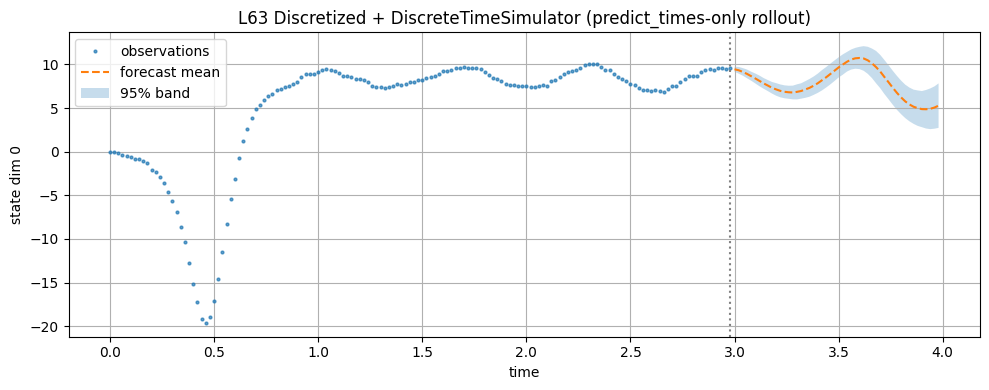

In [7]:
disc_steps = 10000
disc_num_posterior_samples = 200

disc_guide = AutoDiagonalNormal(model_sde)
disc_svi = SVI(model_sde, disc_guide, optax.adam(1e-1), loss=Trace_ELBO())

with DiscreteTimeSimulator():
    with Discretizer():
        disc_result = disc_svi.run(
            jr.PRNGKey(31),
            disc_steps,
            obs_times=obs_times,
            obs_values=obs_values,
        )
        disc_posterior = disc_guide.sample_posterior(
            jr.PRNGKey(32),
            disc_result.params,
            sample_shape=(disc_num_posterior_samples,),
        )
        disc_out = Predictive(
            model_sde,
            posterior_samples=disc_posterior,
            exclude_deterministic=False,
        )(
            jr.PRNGKey(33),
            obs_times=obs_times, # need to include this
            obs_values=obs_values, # need to include this
            predict_times=predict_times,
        )

print("Discrete (linear-Gaussian obs) SVI final ELBO:", float(disc_result.losses[-1]))
_plot_pred_only_from_draws(
    "L63 Discretized + DiscreteTimeSimulator (predict_times-only rollout)",
    obs_times,
    obs_values,
    disc_out["prediction_times"],
    disc_out["predicted_observations"],
    dim=0,
)

Discrete (Dirac obs) predict-only rollout anchored at last observed state.


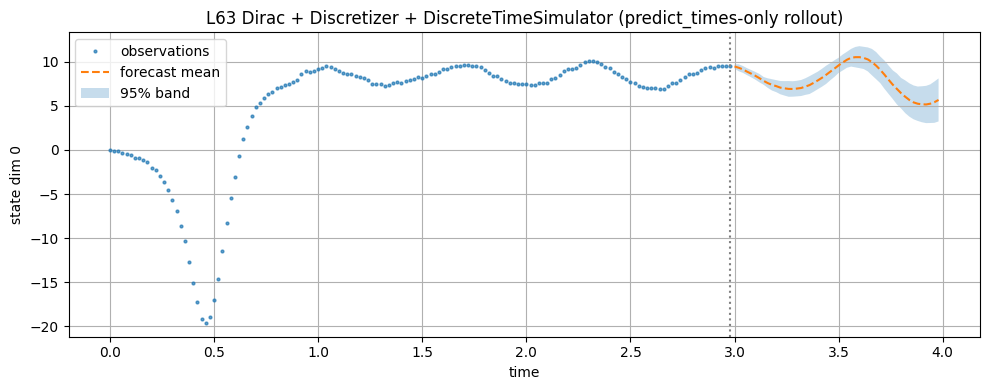

In [8]:

with DiscreteTimeSimulator():
    with Discretizer():
        dirac_out = Predictive(
            model_dirac,
            num_samples=50,
            exclude_deterministic=False,
        )(
            jr.PRNGKey(40),
            obs_times=obs_times,
            obs_values=obs_values,
            predict_times=predict_times,
        )


print("Discrete (Dirac obs) predict-only rollout anchored at last observed state.")
_plot_pred_only_from_draws(
    "L63 Dirac + Discretizer + DiscreteTimeSimulator (predict_times-only rollout)",
    obs_times,
    obs_values,
    dirac_out["prediction_times"],
    dirac_out["predicted_observations"],
    dim=0,
)

## Filter Baseline (Comparison)

This section is a filter-based baseline using the same full-observation setup. Unlike simulator posterior rollouts, filtering naturally conditions on `obs_times` + `obs_values` and forecasts via `predict_times` in one call.

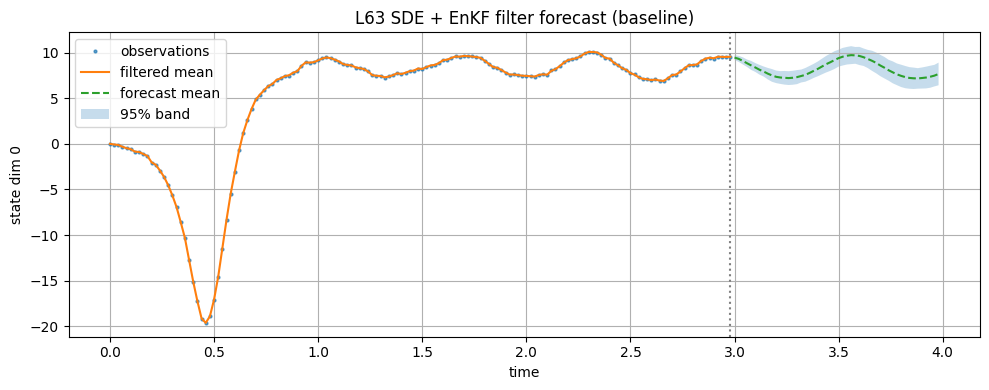

In [9]:
def _plot_filter_forecast(title, obs_times, obs_values, filt_mean, forecast_mean, forecast_cov, dim=0):
    t_obs = jnp.asarray(obs_times)
    y_obs = jnp.asarray(obs_values)[:, dim]
    t_pred = jnp.asarray(predict_times)

    f_mean = jnp.asarray(filt_mean)[:, dim]
    p_mean = jnp.asarray(forecast_mean)[:, dim]
    p_std = jnp.sqrt(jnp.asarray(forecast_cov)[:, dim, dim])

    plt.figure()
    plt.plot(t_obs, y_obs, "o", ms=2, alpha=0.7, label="observations")
    plt.plot(t_obs, f_mean, "-", label="filtered mean")
    plt.plot(t_pred, p_mean, "--", label="forecast mean")
    plt.fill_between(
        t_pred,
        p_mean - 1.96 * p_std,
        p_mean + 1.96 * p_std,
        alpha=0.25,
        label="95% band",
    )
    plt.axvline(float(t_obs[-1]), color="gray", linestyle=":")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(f"state dim {dim}")
    plt.legend(loc="best")
    plt.tight_layout()


enkf_key = jr.PRNGKey(50)
with Filter(filter_config=ContinuousTimeEnKFConfig(n_particles=64)):
    enkf_out = Predictive(
        model_sde,
        num_samples=1,
        exclude_deterministic=False,
    )(
        enkf_key,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

_plot_filter_forecast(
    "L63 SDE + EnKF filter forecast (baseline)",
    obs_times,
    obs_values,
    enkf_out["f_filtered_states_mean"][0],
    enkf_out["f_forecasted_state_means"][0],
    enkf_out["f_forecasted_state_covs"][0],
    dim=0,
)